In [3]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.6 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Load the Best Model

In [7]:
model = YOLO("/content/drive/MyDrive/tomato_project/training/tomato_segmentation/weights/best.pt")

###Evaluate the Model

In [8]:
metrics = model.val(
    data="/content/drive/MyDrive/tomato_project/yolo_dataset/data.yaml"
)

Ultralytics 8.4.93 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n-seg summary (fused): 86 layers, 3,258,454 parameters, 0 gradients, 11.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.6±0.1 ms, read: 0.3±0.2 MB/s, size: 105.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/tomato_project/yolo_dataset/labels/val.cache... 36 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 36/36 6.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 11.8s/it 35.4s
                   all         36        172       0.93      0.825      0.933      0.822      0.894      0.872      0.936       0.81
                unripe         20         87      0.972      0.809      0.962      0.848       0.96      0.862      0.962       0

In [9]:
print(metrics)

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e1cecf9b680>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04104

###Make Predictions on Test Images

In [10]:
test_folder = "/content/drive/MyDrive/tomato_project/yolo_dataset/images/test"

results = model.predict(
    source=test_folder,
    save=True,
    conf=0.25
)


image 1/18 /content/drive/MyDrive/tomato_project/yolo_dataset/images/test/riped_tomato_21.jpeg: 608x640 3 ripes, 319.6ms
image 2/18 /content/drive/MyDrive/tomato_project/yolo_dataset/images/test/riped_tomato_25.jpeg: 640x416 1 unripe, 1 ripe, 320.7ms
image 3/18 /content/drive/MyDrive/tomato_project/yolo_dataset/images/test/riped_tomato_34.jpeg: 448x640 2 ripes, 376.4ms
image 4/18 /content/drive/MyDrive/tomato_project/yolo_dataset/images/test/riped_tomato_38.jpeg: 384x640 2 ripes, 306.6ms
image 5/18 /content/drive/MyDrive/tomato_project/yolo_dataset/images/test/riped_tomato_48.jpeg: 448x640 3 ripes, 206.2ms
image 6/18 /content/drive/MyDrive/tomato_project/yolo_dataset/images/test/riped_tomato_57.jpeg: 608x640 3 ripes, 290.4ms
image 7/18 /content/drive/MyDrive/tomato_project/yolo_dataset/images/test/riped_tomato_71.jpeg: 448x640 1 unripe, 1 ripe, 208.9ms
image 8/18 /content/drive/MyDrive/tomato_project/yolo_dataset/images/test/riped_tomato_85.jpeg: 384x640 2 ripes, 179.3ms
image 9/18 /c

###Locate the Prediction Results

In [11]:
import os

print(os.listdir("runs/segment/predict"))

['unriped_tomato_53.jpg', 'unriped_tomato_61.jpg', 'riped_tomato_34.jpg', 'unriped_tomato_29.jpg', 'unriped_tomato_26.jpg', 'riped_tomato_21.jpg', 'riped_tomato_48.jpg', 'unriped_tomato_77.jpg', 'unriped_tomato_30.jpg', 'riped_tomato_85.jpg', 'unriped_tomato_46.jpg', 'unriped_tomato_2.jpg', 'riped_tomato_57.jpg', 'unriped_tomato_21.jpg', 'riped_tomato_71.jpg', 'riped_tomato_25.jpg', 'riped_tomato_38.jpg', 'unriped_tomato_51.jpg']


###Display One Prediction

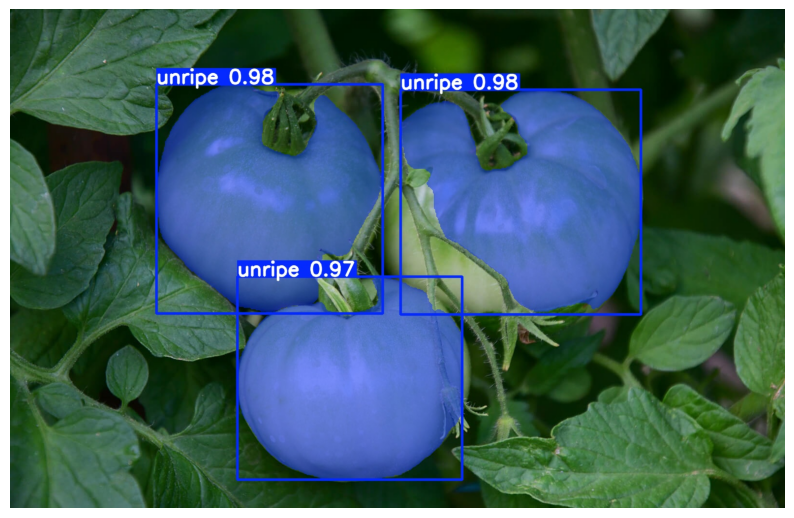

In [12]:
prediction_folder = "runs/segment/predict"

image_name = os.listdir(prediction_folder)[0]

image_path = os.path.join(prediction_folder, image_name)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.imshow(image)
plt.axis("off")
plt.show()

###Evaluate on a Single Image


image 1/1 /content/drive/MyDrive/tomato_project/yolo_dataset/images/test/unriped_tomato_26.jpeg: 384x640 7 unripes, 335.2ms
Speed: 4.9ms preprocess, 335.2ms inference, 19.1ms postprocess per image at shape (1, 3, 384, 640)


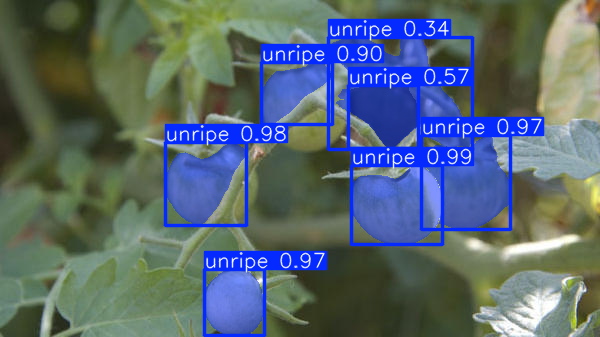

In [13]:
image_path = "/content/drive/MyDrive/tomato_project/yolo_dataset/images/test/" + os.listdir(test_folder)[0]

results = model.predict(
    source=image_path,
    show=False,
    save=False
)

results[0].show()

###Count Detected Tomatoes

In [14]:
results = model.predict(image_path)

print("Total detections:", len(results[0].boxes))


image 1/1 /content/drive/MyDrive/tomato_project/yolo_dataset/images/test/unriped_tomato_26.jpeg: 384x640 7 unripes, 387.1ms
Speed: 4.5ms preprocess, 387.1ms inference, 40.4ms postprocess per image at shape (1, 3, 384, 640)
Total detections: 7


###Print Detection Details

In [15]:
for box in results[0].boxes:

    class_id = int(box.cls)

    confidence = float(box.conf)

    class_name = model.names[class_id]

    print(class_name, confidence)

unripe 0.9881304502487183
unripe 0.9777881503105164
unripe 0.9720693826675415
unripe 0.9664121270179749
unripe 0.8967863917350769
unripe 0.56529301404953
unripe 0.34412190318107605
